<a href="https://colab.research.google.com/github/avindumihisara0229-code/ErgoSense/blob/Lochana/Visual_Stress_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [1]:
!unzip archive.zip

import os

print(os.listdir("/content"))

Streaming output truncated to the last 5000 lines.
  inflating: anger/images - 2020-11-06T004643.968_face.png  
  inflating: anger/images - 2020-11-06T004647.970_face.png  
  inflating: anger/images - 2020-11-06T004648.686_face.png  
  inflating: anger/images - 2020-11-06T004655.143_face.png  
  inflating: anger/images - 2020-11-06T004659.853_face.png  
  inflating: anger/images - 2020-11-06T004703.467_face.png  
  inflating: anger/images - 2020-11-06T004714.287_face.png  
  inflating: anger/images - 2020-11-06T004717.427_face.png  
  inflating: anger/images - 2020-11-06T004717.820_face.png  
  inflating: anger/images - 2020-11-06T004720.711_face.png  
  inflating: anger/images - 2020-11-06T004722.599_face.png  
  inflating: anger/images - 2020-11-06T004728.732_face.png  
  inflating: anger/images - 2020-11-06T004738.914_face.png  
  inflating: anger/images - 2020-11-06T004739.991_face.png  
  inflating: anger/images - 2020-11-06T004743.158_face.png  
  inflating: anger/images - 2020-1

In [2]:
!pip uninstall mediapipe -y

Found existing installation: mediapipe 0.10.20
Uninstalling mediapipe-0.10.20:
  Successfully uninstalled mediapipe-0.10.20


In [3]:
!pip install mediapipe==0.10.20

  Using cached mediapipe-0.10.20-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.20-cp312-cp312-manylinux_2_28_x86_64.whl (35.6 MB)


In [4]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [5]:
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1
)

print("FaceMesh initialized successfully")

FaceMesh initialized successfully


In [6]:
dataset_path = "/content"

emotions = os.listdir(dataset_path)

print("Emotion folders:", emotions)

Emotion folders: ['.config', 'disgust', 'archive.zip', 'anger', 'surprise', 'fear', 'contempt', 'happiness', 'sadness', 'neutrality', 'sample_data']


In [7]:
X = []
y = []

# Filter out non-directory items from emotions and known non-emotion directories
valid_emotions = [e for e in emotions if os.path.isdir(os.path.join(dataset_path, e)) and e not in ['.config', 'sample_data']]

for emotion in valid_emotions:

    emotion_folder = os.path.join(dataset_path, emotion)

    for img_name in os.listdir(emotion_folder):

        img_path = os.path.join(emotion_folder, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        results = face_mesh.process(img_rgb)

        if results.multi_face_landmarks:

            features = []

            for face_landmarks in results.multi_face_landmarks:

                for lm in face_landmarks.landmark:

                    features.append(lm.x)
                    features.append(lm.y)

            X.append(features)
            y.append(emotion)

print("Total samples:", len(X))

Total samples: 4543


In [8]:
X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

Feature shape: (4543, 936)
Labels shape: (4543,)


In [9]:
stress_labels = []

for label in y:

    if label in ["anger","sadness"]:
        stress_labels.append("stress")
    else:
        stress_labels.append("not_stress")

stress_labels = np.array(stress_labels)

print("Classes:", np.unique(stress_labels))

Classes: ['not_stress' 'stress']


In [10]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(stress_labels)

print("Encoded classes:", np.unique(y_encoded))

Encoded classes: [0 1]


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 3634
Test size: 909


In [13]:
models = {
    "SVM": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

accuracies = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies[name] = acc

    print(name, "Accuracy:", acc)

SVM Accuracy: 0.7491749174917491
KNN Accuracy: 0.7216721672167217
Random Forest Accuracy: 0.7546754675467546


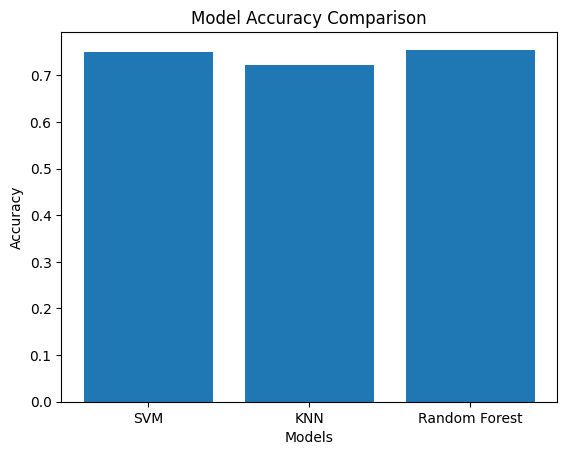

In [14]:
model_names = list(accuracies.keys())
accuracy_values = list(accuracies.values())

plt.figure()

plt.bar(model_names, accuracy_values)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

In [15]:
best_model_name = max(accuracies, key=accuracies.get)

print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Random Forest


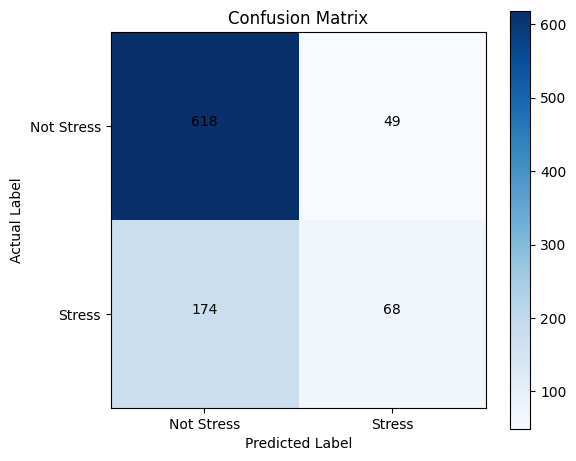

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

labels = ["Not Stress", "Stress"]

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)

# Add numbers inside boxes
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="black")

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")

plt.tight_layout()
plt.show()

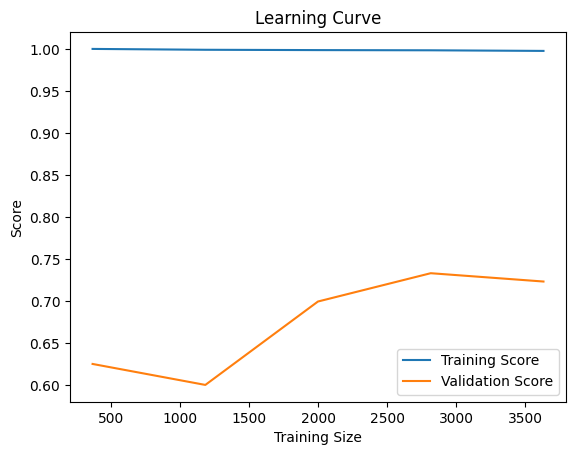

In [17]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_scaled,
    y_encoded,
    cv=5
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure()

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve")

plt.legend()

plt.show()

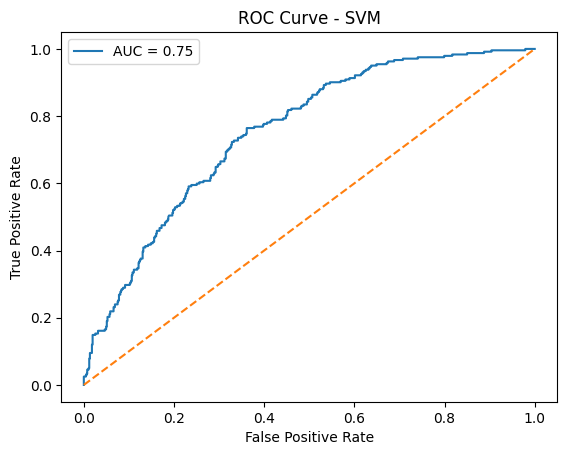

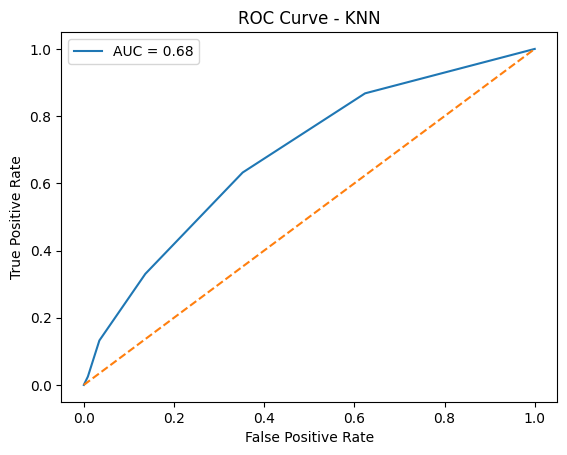

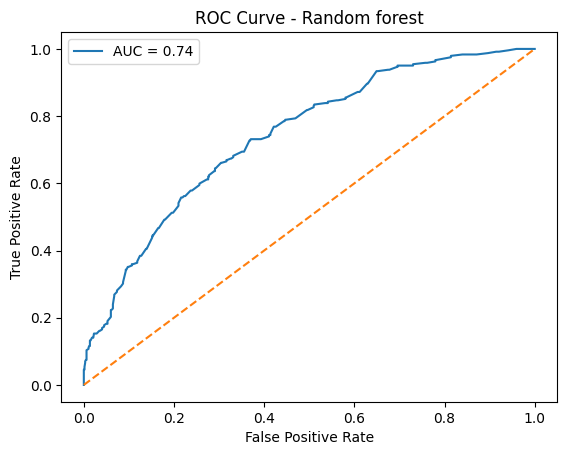

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

models = {
    "SVM": models["SVM"],
    "KNN": models["KNN"],
    "Random forest": models["Random Forest"]
}

# ---------- ROC CURVES ----------
for name, model in models.items():

    # get probability scores
    if name == "SVM":
        y_prob = model.decision_function(X_test)
    else:
        y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

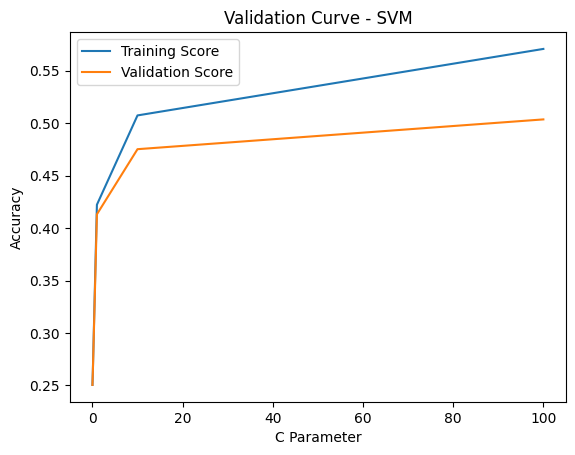

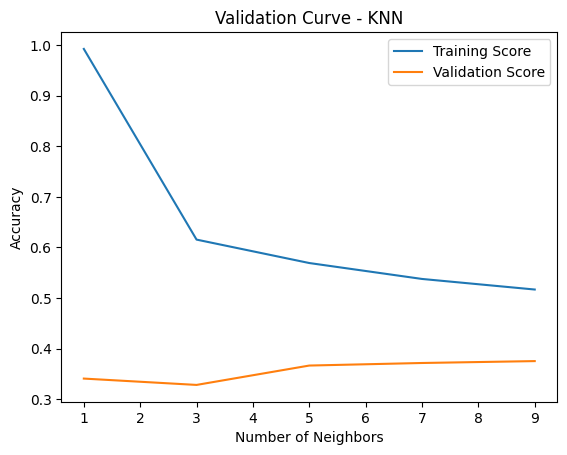

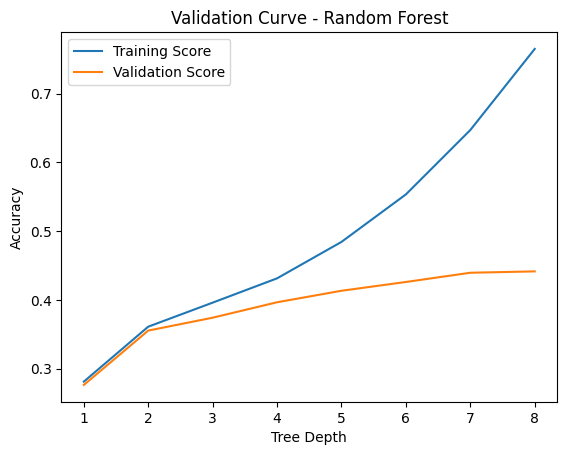

In [19]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
import numpy as np

# -------- SVM Validation Curve --------
param_range = [0.01,0.1,1,10,100]

train_scores, val_scores = validation_curve(
    models["SVM"], X, y,
    param_name="C",
    param_range=param_range,
    cv=5)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure()
plt.plot(param_range, train_mean, label="Training Score")
plt.plot(param_range, val_mean, label="Validation Score")
plt.xlabel("C Parameter")
plt.ylabel("Accuracy")
plt.title("Validation Curve - SVM")
plt.legend()
plt.show()


# -------- KNN Validation Curve --------
param_range = [1,3,5,7,9]

train_scores, val_scores = validation_curve(
    models["KNN"], X, y,
    param_name="n_neighbors",
    param_range=param_range,
    cv=5)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure()
plt.plot(param_range, train_mean, label="Training Score")
plt.plot(param_range, val_mean, label="Validation Score")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.title("Validation Curve - KNN")
plt.legend()
plt.show()


# -------- Random Forest Validation Curve --------
param_range = [1,2,3,4,5,6,7,8]

train_scores, val_scores = validation_curve(
    models["Random forest"], X, y,
    param_name="max_depth",
    param_range=param_range,
    cv=5)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure()
plt.plot(param_range, train_mean, label="Training Score")
plt.plot(param_range, val_mean, label="Validation Score")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Validation Curve - Random Forest")
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import classification_report

# Predict using trained model
y_pred = best_model.predict(X_test)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       667
           1       0.58      0.28      0.38       242

    accuracy                           0.75       909
   macro avg       0.68      0.60      0.61       909
weighted avg       0.73      0.75      0.72       909



In [22]:
import joblib

print("Joblib imported successfully")

Joblib imported successfully


In [23]:
# Save trained best model

joblib.dump(best_model, "stress_detection_model.pkl")

print("Model saved successfully")

Model saved successfully


In [24]:
# Save scaler and encoder

joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")

print("Scaler and encoder saved successfully")

Scaler and encoder saved successfully


In [25]:
# Load saved model

loaded_model = joblib.load("stress_detection_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

print("Model loaded successfully")

Model loaded successfully


In [26]:
# Load saved model

loaded_model = joblib.load("stress_detection_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

print("Model loaded successfully")

Model loaded successfully


In [27]:
# Predict using loaded model

sample = X_test[0].reshape(1,-1)

prediction = loaded_model.predict(sample)

print("Predicted class:", prediction)

Predicted class: [0]


In [32]:
import joblib

# Save trained model
joblib.dump(models["SVM"], "stress_model.joblib")

# Save scaler
joblib.dump(scaler, "scaler.joblib")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [33]:
import os

print(os.listdir())

['.config', 'disgust', 'archive.zip', 'anger', 'surprise', 'stress_detection_model.pkl', 'scaler.joblib', 'scaler.pkl', 'stress_model.joblib', 'fear', 'contempt', 'happiness', 'label_encoder.pkl', 'sadness', 'neutrality', 'sample_data']


In [34]:
from google.colab import files

files.download("stress_detection_model.pkl")
files.download("scaler.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import unittest
import numpy as np
import joblib

class TestVisualStressDetection(unittest.TestCase):

    # Test if dataset path exists
    def test_dataset_path(self):
        import os
        dataset_path = "/content"   # change if needed
        self.assertTrue(os.path.exists(dataset_path))

    # Test if model loads correctly
    def test_model_loading(self):
        model = joblib.load("stress_model.joblib")
        self.assertIsNotNone(model)

    # Test if scaler loads correctly
    def test_scaler_loading(self):
        scaler = joblib.load("scaler.joblib")
        self.assertIsNotNone(scaler)

    # Test prediction output
    def test_model_prediction(self):
        model = joblib.load("stress_model.joblib")
        scaler = joblib.load("scaler.joblib")

        # create dummy feature vector (same length as training features)
        sample = np.random.rand(1, 936)  # change feature size if needed

        sample_scaled = scaler.transform(sample)

        prediction = model.predict(sample_scaled)

        self.assertTrue(prediction[0] in [0,1])

# Run unit tests
unittest.main(argv=[''], verbosity=2, exit=False)

test_dataset_path (__main__.TestVisualStressDetection.test_dataset_path) ... ok
test_model_loading (__main__.TestVisualStressDetection.test_model_loading) ... ok
test_model_prediction (__main__.TestVisualStressDetection.test_model_prediction) ... ok
test_scaler_loading (__main__.TestVisualStressDetection.test_scaler_loading) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.042s

OK
